<a href="https://colab.research.google.com/github/Teixeiras15-collab/Atividades/blob/main/Atividade_Pr%C3%A1tica_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Gerando dados sintéticos estruturados
np.random.seed(42)
n_registros = 120

datas = pd.date_range(start='2024-01-01', periods=n_registros, freq='D')
categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
    'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)


# **Parte 1: Gráficos Essenciais e Personalização (Básico)**

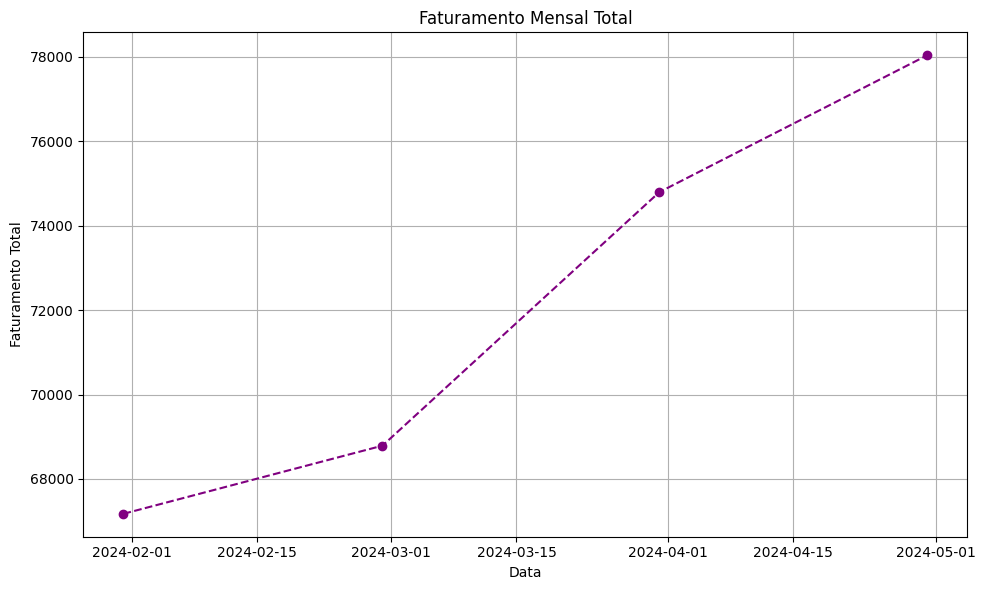

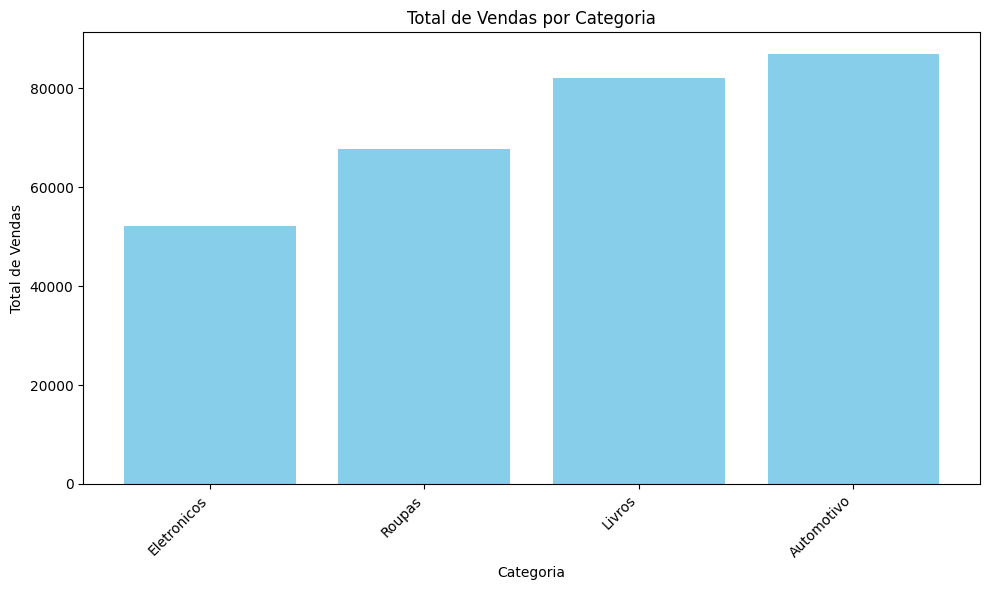

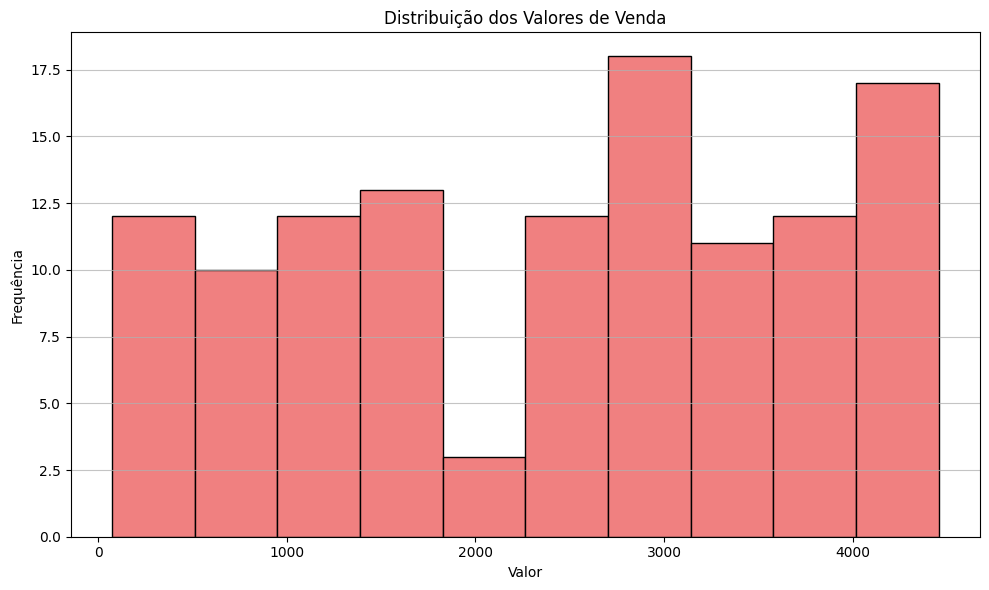

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Gráfico de linha do faturamento mensal total
# Resample para obter o faturamento mensal
df_mensal = df.set_index('data')['valor_venda'].resample('ME').sum()

plt.figure(figsize=(10, 6))
plt.plot(df_mensal.index, df_mensal.values, marker='o', linestyle='--', color='purple')
plt.title('Faturamento Mensal Total')
plt.xlabel('Data')
plt.ylabel('Faturamento Total')
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Gráfico de barras do total de vendas por categoria
vendas_por_categoria = df.groupby('categoria')['valor_venda'].sum().sort_values()

plt.figure(figsize=(10, 6))
plt.bar(vendas_por_categoria.index, vendas_por_categoria.values, color='skyblue')
plt.title('Total de Vendas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Total de Vendas')
plt.xticks(rotation=45, ha='right') # Rotacionar rótulos do eixo X
plt.tight_layout()
plt.show()

# 3. Histograma da coluna valor
plt.figure(figsize=(10, 6))
plt.hist(df['valor'], bins=10, edgecolor='black', color='lightcoral')
plt.title('Distribuição dos Valores de Venda')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# **Parte 2: API Orientada a Objetos e Eixos Múltiplos (Intermediário)**

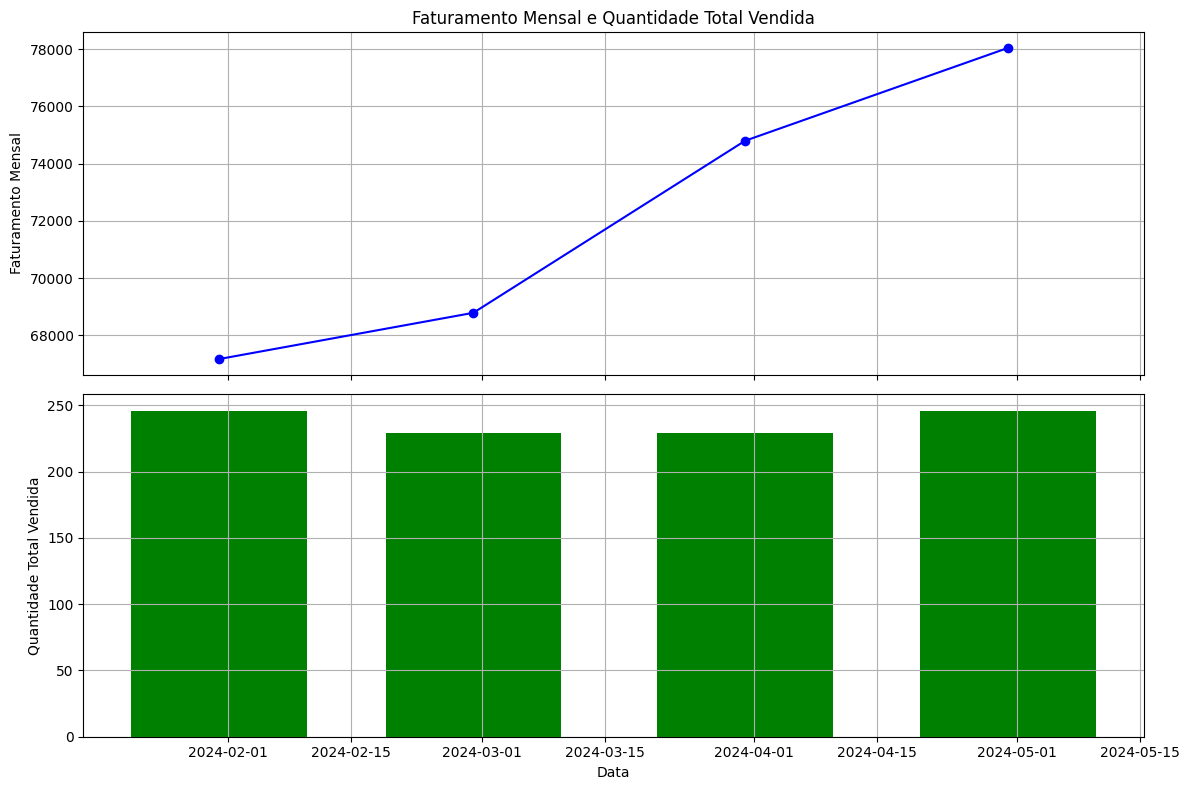

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare monthly data
df_monthly = df.set_index('data').resample('ME').agg({
    'valor_venda': 'sum',
    'quantidade': 'sum'
}).rename(columns={'valor_venda': 'faturamento_mensal', 'quantidade': 'quantidade_total_vendida'})
df_monthly['quantidade_media_por_venda'] = df_monthly['faturamento_mensal'] / df_monthly['quantidade_total_vendida']

# 4. Crie uma figura com uma grade 2 x 1 de subplots (fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)) com o eixo X compartilhado:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))

# 5. ax1 (Superior): Gráfico de linha com o faturamento mensal.
ax1.plot(df_monthly.index, df_monthly['faturamento_mensal'], marker='o', linestyle='-', color='blue')
ax1.set_title('Faturamento Mensal e Quantidade Total Vendida')
ax1.set_ylabel('Faturamento Mensal')
ax1.grid(True)

# 6. ax2 (Inferior): Gráfico de barras com a quantidade total de itens vendidos no mesmo período.
ax2.bar(df_monthly.index, df_monthly['quantidade_total_vendida'], color='green', width=20)
ax2.set_xlabel('Data')
ax2.set_ylabel('Quantidade Total Vendida')
ax2.grid(True)

plt.tight_layout()
plt.show()

# **Parte 3: Matriz de Intensidade / Heatmap (Intermediário / Avançado)**

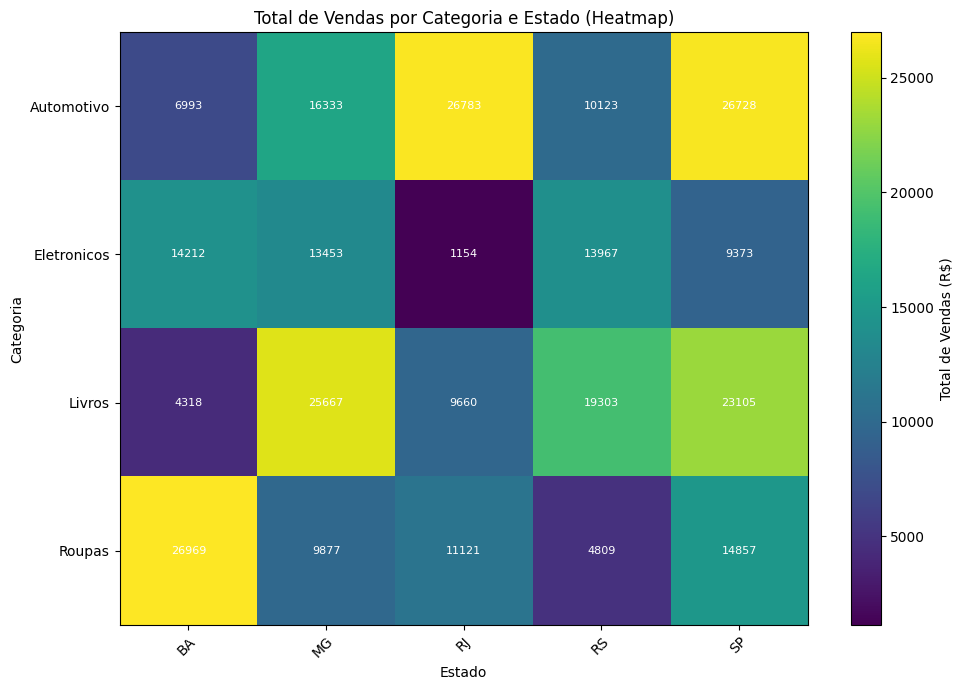

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 7. Construa uma tabela dinâmica (pd.pivot_table) somando os valores de venda agrupados por categoria nas linhas e estado nas colunas.
pivot_table_df = pd.pivot_table(df, values='valor_venda', index='categoria', columns='estado', aggfunc='sum', fill_value=0)

# 8. Renderize essa matriz na forma de um Heatmap utilizando plt.imshow(), incluindo uma barra de cores (plt.colorbar()) e os respectivos rótulos nominais nas marcações dos eixos X (xticks) e Y (yticks).
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(pivot_table_df.values, cmap='viridis', aspect='auto')

# Adicionar barra de cores
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Total de Vendas (R$)')

# Rótulos para os eixos X e Y
ax.set_xticks(np.arange(len(pivot_table_df.columns)))
ax.set_yticks(np.arange(len(pivot_table_df.index)))
ax.set_xticklabels(pivot_table_df.columns)
ax.set_yticklabels(pivot_table_df.index)

# Rotacionar os rótulos do eixo X se necessário
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Adicionar valores nas células (opcional, para melhor visualização)
for i in range(len(pivot_table_df.index)):
    for j in range(len(pivot_table_df.columns)):
        text = ax.text(j, i, f'{pivot_table_df.iloc[i, j]:.0f}',
                       ha="center", va="center", color="w", fontsize=8)

ax.set_title('Total de Vendas por Categoria e Estado (Heatmap)')
ax.set_xlabel('Estado')
ax.set_ylabel('Categoria')

plt.tight_layout()

# 9. Salve a figura gerada no passo 8 em um arquivo de imagem 'heatmap_vendas.png' com resolução de 300 DPI e corte ajustado (bbox_inches='tight').
plt.savefig('heatmap_vendas.png', dpi=300, bbox_inches='tight')

plt.show()